# 1. Import Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import Ridge

# 2. Download French Equity Data

In [4]:
tickers = [
    "MC.PA", "TTE.PA", "AIR.PA", "BNP.PA",
    "OR.PA", "SAN.PA", "SU.PA", "CS.PA",
    "^FCHI"
]

data = yf.download(tickers, start="2010-01-01", end="2025-12-31")["Close"]
data = data.dropna()

/tmp/ipykernel_55/510958004.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01", end="2025-12-31")["Close"]
[*********************100%***********************]  9 of 9 completed


# 3. Monthly Returns Engine

In [5]:
monthly_prices = data.resample("M").last()
monthly_returns = monthly_prices.pct_change().dropna()

benchmark = monthly_returns["^FCHI"]
stocks = monthly_returns.drop(columns="^FCHI")

/tmp/ipykernel_55/2143089176.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = data.resample("M").last()


# 🧠 FACTOR CONSTRUCTION

## Momentum (12M - 1M)

In [6]:
momentum = monthly_prices.pct_change(12) - monthly_prices.pct_change(1)
momentum = momentum.dropna()

## Low Volatility (6M rolling std)

In [11]:
volatility = monthly_returns.rolling(6).std()
volatility = volatility.dropna()

## Beta Factor (Rolling 12M)

In [7]:
rolling_beta = pd.DataFrame(index=monthly_returns.index, columns=stocks.columns)

for stock in stocks.columns:
    for i in range(12, len(monthly_returns)):
        y = stocks[stock].iloc[i-12:i]
        x = benchmark.iloc[i-12:i]
        beta, _, _, _, _ = stats.linregress(x, y)
        rolling_beta.iloc[i, rolling_beta.columns.get_loc(stock)] = beta

rolling_beta = rolling_beta.dropna()

## REGIME DETECTION

**High volatility regime if market 6M volatility > median.**

In [8]:
market_vol = benchmark.rolling(6).std()
vol_threshold = market_vol.median()

regime = (market_vol > vol_threshold).astype(int)


**1 = High Volatility Regime
0 = Low Volatility Regime**
****

## MULTI-FACTOR SCORE

In [12]:
def zscore(df):
    return (df - df.mean()) / df.std()

mom_z = zscore(momentum)
vol_z = zscore(-volatility)  # negative because low vol better
beta_z = zscore(-rolling_beta)

common_index = mom_z.index.intersection(vol_z.index).intersection(beta_z.index)

factor_score = mom_z.loc[common_index] + vol_z.loc[common_index] + beta_z.loc[common_index]

## CROSS-SECTIONAL PORTFOLIO CONSTRUCTION

In [15]:
portfolio_returns = []
turnover = []

prev_weights = None

for date in factor_score.index:
    
    scores = factor_score.loc[date]
    top_n = int(len(scores) * 0.3)
    selected = scores.sort_values(ascending=False).head(top_n).index
    
    weights = pd.Series(0, index=stocks.columns)
    weights[selected] = 1 / top_n
    
    if prev_weights is not None:
        turnover.append(np.abs(weights - prev_weights).sum())
    else:
        turnover.append(0)
    
    portfolio_returns.append((stocks.loc[date] * weights).sum())
    prev_weights = weights

portfolio_returns = pd.Series(portfolio_returns, index=factor_score.index)
turnover = pd.Series(turnover, index=factor_score.index)

/tmp/ipykernel_55/3880248163.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[selected] = 1 / top_n
/tmp/ipykernel_55/3880248163.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[selected] = 1 / top_n
/tmp/ipykernel_55/3880248163.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[selected] = 1 / top_n
/tmp/ipykernel_55/3880248163.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a f

## TRANSACTION COST ADJUSTMENT

Assume 20 bps cost per turnover.

In [16]:
transaction_cost = 0.002 * turnover
net_returns = portfolio_returns - transaction_cost

## WALK-FORWARD VALIDATION

In [17]:
train_period = 60
test_period = 24

wf_returns = []

for start in range(0, len(net_returns) - train_period - test_period, test_period):
    train = net_returns.iloc[start:start+train_period]
    test = net_returns.iloc[start+train_period:start+train_period+test_period]
    wf_returns.append(test)

wf_returns = pd.concat(wf_returns)

## ROLLING ALPHA STABILITY TEST

In [19]:
rolling_alpha = []

for i in range(24, len(net_returns)):
    y = net_returns.iloc[i-24:i]
    x = benchmark.loc[y.index]
    beta, alpha, _, _, _ = stats.linregress(x, y)
    rolling_alpha.append(alpha)

rolling_alpha = pd.Series(rolling_alpha, index=net_returns.index[24:])

## ROBUST PORTFOLIO OPTIMIZATION (RIDGE REGULARIZATION

In [20]:
mean_returns = stocks.mean() * 12
cov_matrix = stocks.cov() * 12

ridge = Ridge(alpha=1.0)
ridge.fit(cov_matrix, mean_returns)
optimal_weights = ridge.coef_
optimal_weights = optimal_weights / np.sum(optimal_weights)

## PERFORMANCE ANALYTICS

In [21]:
def performance_metrics(returns):
    ann_return = returns.mean() * 12
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol
    cumulative = (1 + returns).cumprod()
    max_dd = (cumulative / cumulative.cummax() - 1).min()
    return ann_return, ann_vol, sharpe, max_dd

metrics = performance_metrics(net_returns)
metrics

(np.float64(0.13141646503689378),
 np.float64(0.15702929054257758),
 np.float64(0.8368914142247937),
 -0.21887542151882033)

# 📈 Plot Strategy vs CAC 40

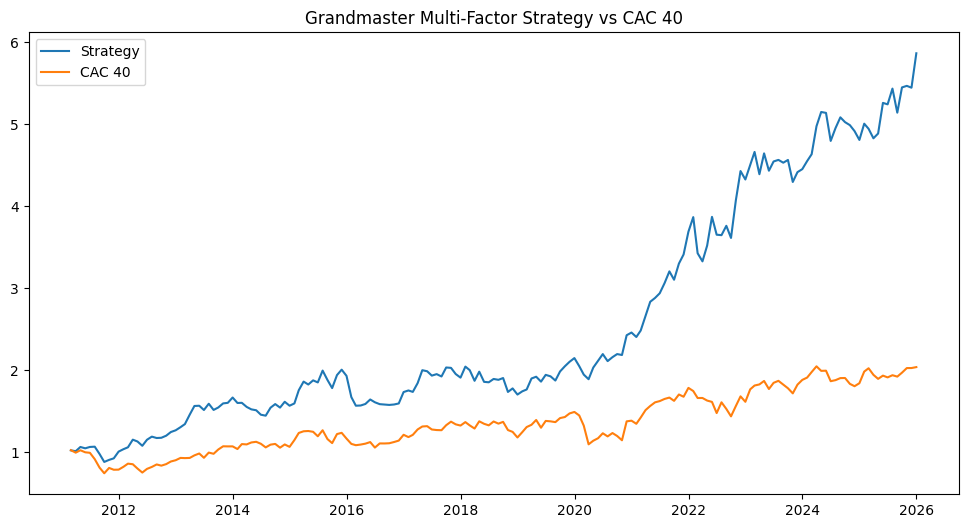

In [22]:
plt.figure(figsize=(12,6))
plt.plot((1+net_returns).cumprod(), label="Strategy")
plt.plot((1+benchmark.loc[net_returns.index]).cumprod(), label="CAC 40")
plt.legend()
plt.title("Grandmaster Multi-Factor Strategy vs CAC 40")
plt.show()